In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
# 2. LOAD CLEANED DATASET
folder = r"C:\Users\omars\Downloads"
file = "NYC_Taxi_Cleaned_Final_Version.csv"
df = pd.read_csv(f"{folder}\\{file}")

print("Original dataset shape:", df.shape)

Original dataset shape: (8674609, 21)


In [3]:
# 3. SAMPLE DATASET TO REDUCE MEMORY
df = df.sample(50000, random_state=42)  # sample 50k rows
print("Sampled dataset shape:", df.shape)

Sampled dataset shape: (50000, 21)


In [4]:
# 4. SELECT CATEGORICAL + BIN NUMERIC COLUMNS
df_cat = pd.DataFrame()

# Keep categorical columns
df_cat['VendorID']           = df['VendorID']
df_cat['passenger_count']    = df['passenger_count']
df_cat['RatecodeID']         = df['RatecodeID']
df_cat['store_and_fwd_flag'] = df['store_and_fwd_flag']
df_cat['PULocationID']       = df['PULocationID']
df_cat['DOLocationID']       = df['DOLocationID']
df_cat['payment_type']       = df['payment_type']
df_cat['source_month']       = df['source_month']
df_cat['pickup_hour']        = df['pickup_hour']
df_cat['pickup_day']         = df['pickup_day']

In [6]:
# Bin numeric columns into 5 categories each
df_cat['trip_distance_bin'] = pd.cut(df['trip_distance'], bins=5, labels=False)
df_cat['fare_bin']          = pd.cut(df['fare_amount'], bins=5, labels=False)
df_cat['duration_bin']      = pd.cut(df['trip_duration'], bins=5, labels=False)
df_cat['total_bin']         = pd.cut(df['total_amount'], bins=5, labels=False)
print("Categorical + binned dataframe shape:", df_cat.shape)

Categorical + binned dataframe shape: (50000, 14)


In [7]:
# 5. CONVERT ALL COLUMNS TO STRING (to ensure binary dummies)
for col in df_cat.columns:
    df_cat[col] = df_cat[col].astype(str)

In [8]:
# 6. ONE-HOT ENCODING
df_onehot = pd.get_dummies(df_cat, dtype=bool)
print("One-hot encoded shape:", df_onehot.shape)


One-hot encoded shape: (50000, 509)


In [9]:
# 7. RUN APRIORI
frequent_itemsets = apriori(
    df_onehot,
    min_support=0.02,  # minimum 2% support
    use_colnames=True,
    max_len=3          # limit combinations to avoid memory explosion
)
print("Frequent itemsets shape:", frequent_itemsets.shape)
display(frequent_itemsets.head(10))

Frequent itemsets shape: (3289, 2)


,support,itemsets
0,0.24688,(VendorID_0)
1,0.75312,(VendorID_1)
2,0.75892,(passenger_count_1.0)
3,0.14612,(passenger_count_2.0)
4,0.03724,(passenger_count_3.0)
5,0.02260,(passenger_count_4.0)
6,0.99286,(RatecodeID_0)
7,0.99512,(store_and_fwd_flag_0)
8,0.02070,(PULocationID_139)
9,0.03486,(PULocationID_141)


In [10]:
# 8. GENERATE ASSOCIATION RULES
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)
print("Number of rules generated:", rules.shape[0])
display(rules.head(10))

Number of rules generated: 10110


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(payment_type_1),(VendorID_0),0.16398,0.24688,0.04110,0.250640,1.015231,1.0,0.000617,1.005018,0.017946,0.111153,0.004993,0.208559
1,(VendorID_0),(payment_type_1),0.24688,0.16398,0.04110,0.166478,1.015231,1.0,0.000617,1.002996,0.019921,0.111153,0.002988,0.208559
2,(VendorID_0),(source_month_December),0.24688,0.33032,0.08378,0.339355,1.027353,1.0,0.002231,1.013676,0.035352,0.169794,0.013492,0.296494
3,(source_month_December),(VendorID_0),0.33032,0.24688,0.08378,0.253633,1.027353,1.0,0.002231,1.009048,0.039757,0.169794,0.008966,0.296494
4,(trip_distance_bin_0),(VendorID_0),0.64416,0.24688,0.16320,0.253353,1.026220,1.0,0.004170,1.008670,0.071802,0.224225,0.008595,0.457202
5,(VendorID_0),(trip_distance_bin_0),0.24688,0.64416,0.16320,0.661050,1.026220,1.0,0.004170,1.049830,0.033926,0.224225,0.047465,0.457202
6,(VendorID_0),(fare_bin_1),0.24688,0.38786,0.10194,0.412913,1.064593,1.0,0.006185,1.042674,0.080564,0.191329,0.040927,0.337870
7,(fare_bin_1),(VendorID_0),0.38786,0.24688,0.10194,0.262827,1.064593,1.0,0.006185,1.021632,0.099118,0.191329,0.021174,0.337870
8,(VendorID_0),(duration_bin_2),0.24688,0.23168,0.05766,0.233555,1.008092,1.0,0.000463,1.002446,0.010658,0.136992,0.002440,0.241216
9,(duration_bin_2),(VendorID_0),0.23168,0.24688,0.05766,0.248878,1.008092,1.0,0.000463,1.002660,0.010448,0.136992,0.002653,0.241216


In [11]:
# 9. SORT RULES BY LIFT
rules_sorted = rules.sort_values(by='lift', ascending=False)
display(rules_sorted.head(10))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
10015,(duration_bin_3),"(fare_bin_3, trip_distance_bin_1)",0.06006,0.03236,0.02126,0.353979,10.938793,1.0,0.019316,1.497847,0.966639,0.298763,0.332375,0.505482
10014,"(fare_bin_3, trip_distance_bin_1)",(duration_bin_3),0.03236,0.06006,0.02126,0.656984,10.938793,1.0,0.019316,2.740221,0.938967,0.298763,0.635066,0.505482
9245,(total_bin_1),"(payment_type_1, duration_bin_0)",0.11596,0.02366,0.02228,0.192135,8.120677,1.0,0.019536,1.208544,0.991875,0.189876,0.172558,0.566904
9244,"(payment_type_1, duration_bin_0)",(total_bin_1),0.02366,0.11596,0.02228,0.941674,8.120677,1.0,0.019536,15.156802,0.898107,0.189876,0.934023,0.566904
10016,(fare_bin_3),"(duration_bin_3, trip_distance_bin_1)",0.11432,0.02324,0.02126,0.185969,8.002117,1.0,0.018603,1.199905,0.987979,0.182803,0.166601,0.550386
10013,"(duration_bin_3, trip_distance_bin_1)",(fare_bin_3),0.02324,0.11432,0.02126,0.914802,8.002117,1.0,0.018603,10.395557,0.895853,0.182803,0.903805,0.550386
10109,(fare_bin_3),"(duration_bin_3, total_bin_3)",0.11432,0.04510,0.04108,0.359342,7.967676,1.0,0.035924,1.490499,0.987369,0.347135,0.329084,0.635103
10104,"(duration_bin_3, total_bin_3)",(fare_bin_3),0.04510,0.11432,0.04108,0.910865,7.967676,1.0,0.035924,9.936360,0.915795,0.347135,0.899360,0.635103
10107,(duration_bin_3),"(total_bin_3, fare_bin_3)",0.06006,0.09224,0.04108,0.683983,7.415250,1.0,0.035540,2.872501,0.920423,0.369358,0.651871,0.564671
10106,"(total_bin_3, fare_bin_3)",(duration_bin_3),0.09224,0.06006,0.04108,0.445360,7.415250,1.0,0.035540,1.694685,0.953052,0.369358,0.409920,0.564671


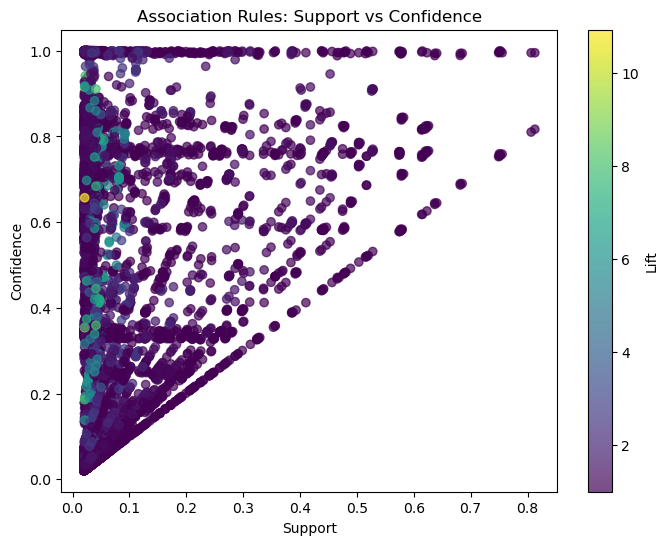

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='viridis',
    alpha=0.7
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence')
plt.show()

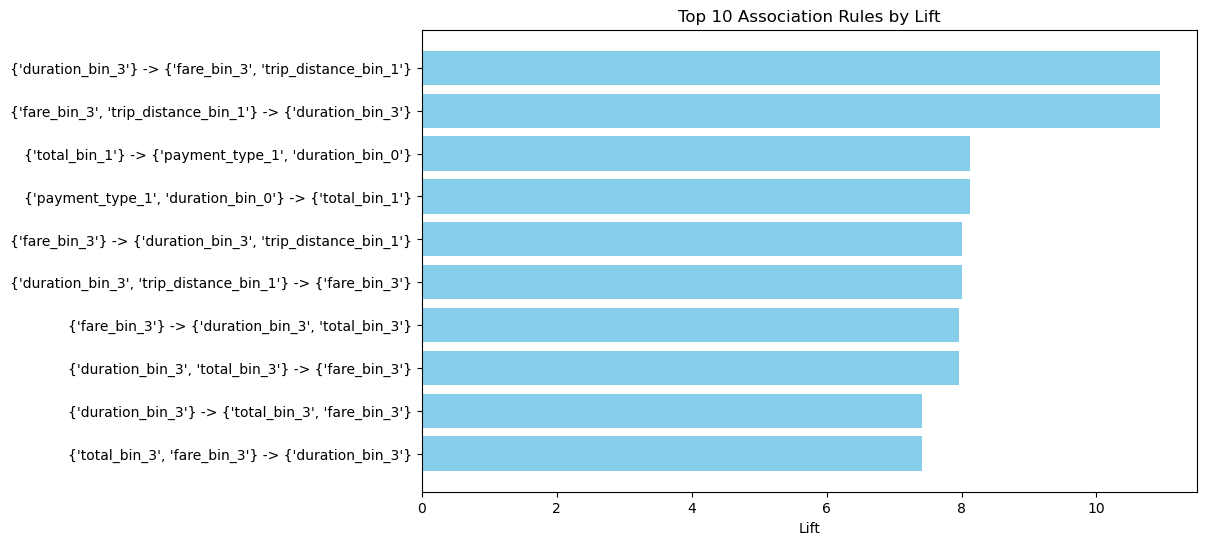

In [13]:
top_rules = rules.sort_values(by='lift', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(
    y=range(len(top_rules)),
    width=top_rules['lift'],
    color='skyblue'
)
plt.yticks(range(len(top_rules)), 
           [f"{set(a)} -> {set(b)}" for a, b in zip(top_rules['antecedents'], top_rules['consequents'])])
plt.xlabel('Lift')
plt.title('Top 10 Association Rules by Lift')
plt.gca().invert_yaxis()  # highest lift on top
plt.show()

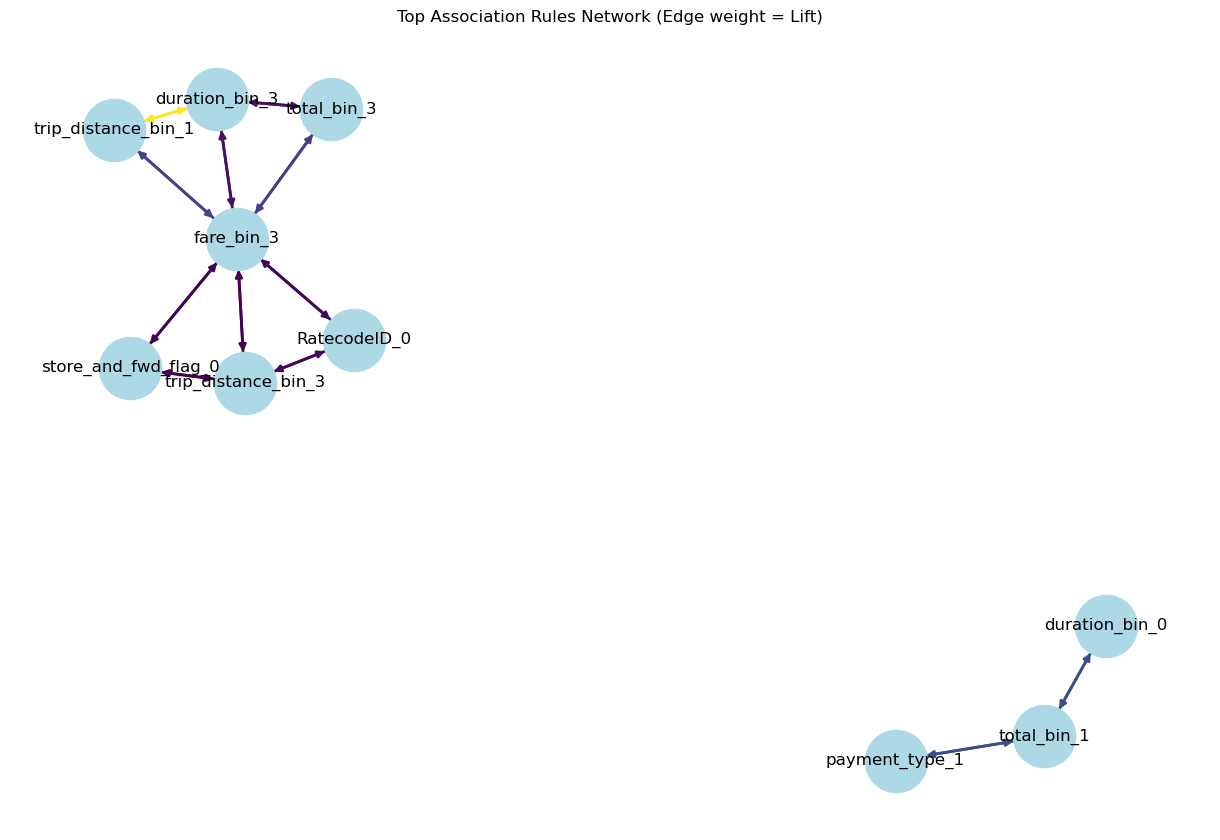

In [14]:
import networkx as nx

G = nx.DiGraph()

# Only include top 20 rules for readability
top_rules = rules.sort_values(by='lift', ascending=False).head(20)

for _, row in top_rules.iterrows():
    for ant in row['antecedents']:
        for con in row['consequents']:
            G.add_edge(ant, con, weight=row['lift'])

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=1)
edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, 
        edge_color=weights, width=2.0, edge_cmap=plt.cm.viridis)
plt.title("Top Association Rules Network (Edge weight = Lift)")
plt.show()